In [1]:
#Importar la librería NumPy, pandas y matplotlib.pyplot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Importar el archivo “supermarket_sales.csv”
df = pd.read_csv('supermarket_sales.csv')

In [2]:
df.head(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
# Generar estadística descriptiva básica en las columnas unit_price y quantity: Cálculo de la media, mediana, moda
unit_price_np = df['Unit price'].to_numpy()
quantity_np = df['Quantity'].to_numpy()

print('Media de unit_price: ', np.mean(unit_price_np))
print('Media de quantity: ', np.mean(quantity_np))

print('Mediana de unit_price: ', np.mean(unit_price_np))
print('Mediana de quantity: ', np.median(quantity_np))

vals, counts = np.unique(unit_price_np,return_counts=True)
index = np.argmax(counts)
moda = vals[index]
print('Moda(s) de unit_price: ', moda)

vals, counts = np.unique(quantity_np, return_counts=True)
index = np.argmax(counts)
moda = vals[index]
print('Moda(s) de quantity: ', moda)

Media de unit_price:  55.67213
Media de quantity:  5.51
Mediana de unit_price:  55.67213
Mediana de quantity:  5.0
Moda(s) de unit_price:  83.77
Moda(s) de quantity:  10


In [35]:
#Obtener el ticket promedio:
#1) por ciudad,
#2) por product line y ciudad,
#3) por género,
#4) por género y product line
ticket_promedio_ciudad = df.groupby('City')['Total'].apply(np.mean) 
ticket_promedio_product_line_ciudad = df.groupby(['Product line', 'City'])['Total'].apply(np.mean)
ticket_promedio_genero = df.groupby('Gender')['Total'].apply(np.mean)
ticket_promedio_genero_product_line = df.groupby(['Gender', 'Product line'])['Total'].apply(np.mean)


In [36]:
print(ticket_promedio_ciudad)
print(ticket_promedio_product_line_ciudad)
print(ticket_promedio_genero)
print(ticket_promedio_genero_product_line)


City
Mandalay     319.872506
Naypyitaw    337.099715
Yangon       312.354031
Name: Total, dtype: float64
Product line            City     
Electronic accessories  Mandalay     310.026245
                        Naypyitaw    344.890445
                        Yangon       305.285225
Fashion accessories     Mandalay     264.730911
                        Naypyitaw    331.693385
                        Yangon       320.245265
Food and beverages      Mandalay     304.297770
                        Naypyitaw    360.103864
                        Yangon       295.915526
Health and beauty       Mandalay     376.993585
                        Naypyitaw    319.525500
                        Yangon       268.037298
Home and lifestyle      Mandalay     350.983290
                        Naypyitaw    308.790067
                        Yangon       344.879931
Sports and travel       Mandalay     322.390306
                        Naypyitaw    350.265067
                        Yangon       328.3508

In [ ]:
#función para mostrar el porcentaje de ventas por categoría
def mensaje_porcentaje(porcentajes):
    mensaje = ''
    for i, porcentaje in porcentajes.items():
        print(f'El porcentaje de ventas para {i} es: {porcentaje:.2f}%')
    return mensaje
    

El porcentaje de ventas para Naypyitaw es: 34.24%
El porcentaje de ventas para Yangon es: 32.88%
El porcentaje de ventas para Mandalay es: 32.88%



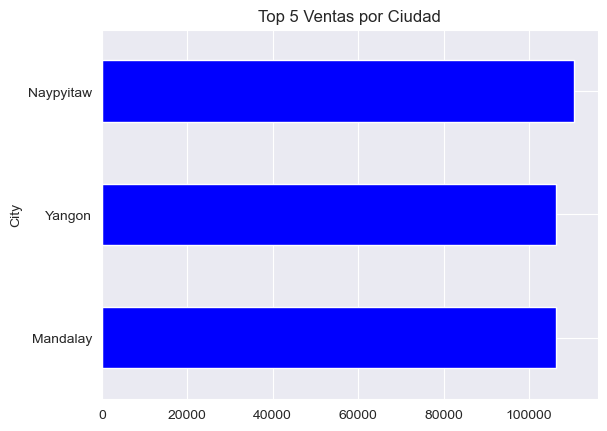

In [60]:
#Usar el método rank para generar top 5 de:
#1) ventas por ciudad,

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

sns.set_style('darkgrid')

ventas_ciudad = df.groupby('City')['Total'].sum()
ventas_ciudad_ranking = ventas_ciudad.rank(ascending=False, method='dense')
ventas_ciudad_top5 = ventas_ciudad[ventas_ciudad_ranking  <= 5].sort_values(ascending=False)
ventas_ciudad_top5
ax = ventas_ciudad_top5[::-1].plot.barh(y='City',x='Total',color='b',title='Top 5 Ventas por Ciudad')

porcentaje_ventas_ciudad = ventas_ciudad_top5/ventas_ciudad.sum() * 100
print(mensaje_porcentaje(porcentaje_ventas_ciudad))



El porcentaje de ventas para Member es: 50.85%
El porcentaje de ventas para Normal es: 49.15%



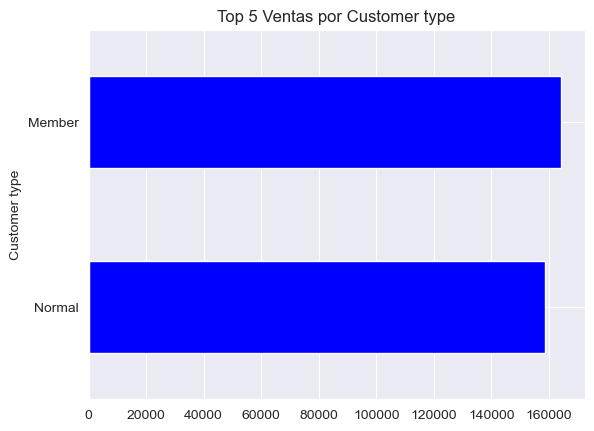

In [59]:
#2) ventas por member,

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

sns.set_style('darkgrid')

ventas_customer_type = df.groupby('Customer type')['Total'].sum()
ventas_customer_type_ranking = ventas_customer_type.rank(ascending=False, method='dense')
ventas_customer_type_top5 = ventas_customer_type[ventas_customer_type_ranking  <= 5].sort_values(ascending=False)
ventas_customer_type_top5
ax = ventas_customer_type_top5[::-1].plot.barh(y='Customer type',x='Total',color='b',title='Top 5 Ventas por Customer type')

porcentaje_ventas_customer_type = ventas_customer_type_top5/ventas_customer_type.sum() * 100
print(mensaje_porcentaje(porcentaje_ventas_customer_type))

El porcentaje de ventas para Cash es: 34.74%
El porcentaje de ventas para Ewallet es: 34.06%
El porcentaje de ventas para Credit card es: 31.20%



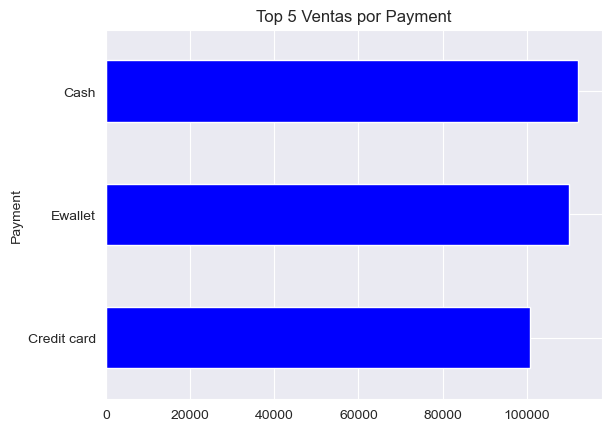

In [58]:
#3) ventas por payment. Obtener además el % de aporte de cada categoría. 

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

sns.set_style('darkgrid')

ventas_payment = df.groupby('Payment')['Total'].sum()
ventas_payment_ranking = ventas_payment.rank(ascending=False, method='dense')
ventas_payment_top5 = ventas_payment[ventas_payment_ranking  <= 5].sort_values(ascending=False)
ventas_payment_top5
ax = ventas_payment_top5[::-1].plot.barh(y='Payment',x='Total',color='b',title='Top 5 Ventas por Payment')


porcentaje_ventas_payment = ventas_payment_top5/ventas_payment.sum() * 100
print(mensaje_porcentaje(porcentaje_ventas_payment))


In [73]:
#Cálculo de una matriz de correlación entre la hora (sin minutos) y el total, 
# y otra que correlacione el unit_price con el rating de la transacción, 
# para validar si los productos más caros son los que dejan más margen
df['Hour'] = df['Time'].str.split(':').str[0].astype(int)
df.sample(1)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour
630,149-61-1929,A,Yangon,Normal,Male,Sports and travel,64.19,10,32.095,673.995,1/19/2019,14:08,Credit card,641.9,4.761905,32.095,6.7,14


Text(0, 0.5, 'Total')

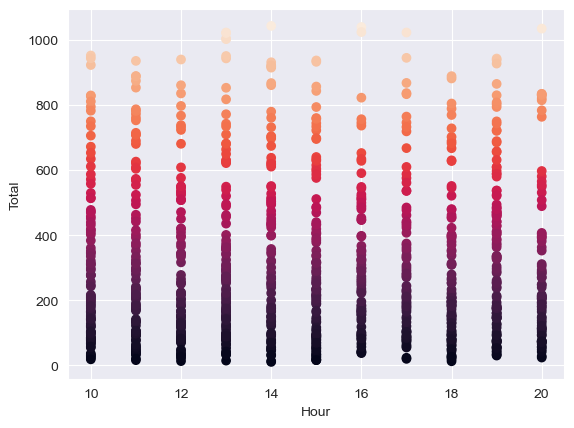

In [85]:
#Cálculo de una matriz de correlación entre la hora (sin minutos) y el total, 
np_hour = df['Hour'].to_numpy()
np_total = df['Total'].to_numpy()

np.corrcoef(np_hour,np_total)
plt.scatter(x=np_hour, y=np_total, c=np_total)
plt.xlabel('Hour')
plt.ylabel('Total')


Text(0, 0.5, 'Rating')

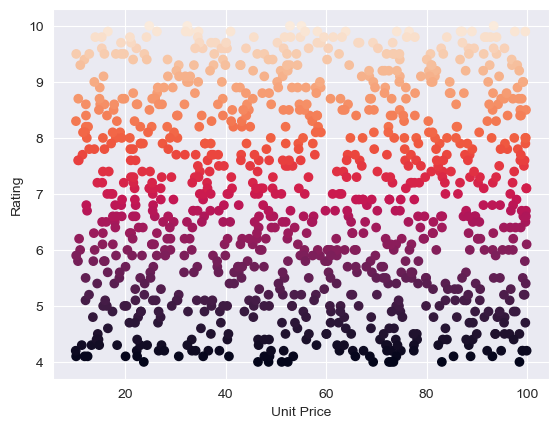

In [ ]:
#Cálculo de una matriz de correlación entre el unit_price con el rating de la transacción, 
# para validar si los productos más caros son los que dejan más margen
np_rating =df['Rating'].to_numpy()
np_unit_price = df['Unit price'].to_numpy()

np.corrcoef(np_unit_price, np_rating)
plt.scatter(x=np_unit_price, y= np_rating, c=np_rating)
plt.xlabel('Unit Price')
plt.ylabel('Rating')